In [10]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import datasets.data_loader as data_loader
from utils import generate_dataset

import matplotlib.pyplot as plt
from scipy.io import loadmat
import os
import numpy as np
from collections import Counter
import csv

# Load Model
from models.model_components import CALoRa, CALoRa_Visualizer
import torch.optim as optim

from collections import defaultdict
import random
from LoRa import LoRa

torch.cuda.empty_cache()

In [14]:
# Define dummy options class for maskCNNModel
class Opts:
    # LoRa Configuration
    sf=7
    fs = 1e6
    bw = 125e3
    n_classes = int(2**sf)      # 128
    
    # Model Configuration
    x_image_channel = 2
    y_image_channel = 2
    conv_dim_lstm = int(n_classes*8)
    lstm_dim = 400
    fc1_dim = 600
    ratio_bt_train_and_test = 0.8
    batch_size = 16
    num_workers = 1
    normalization = True
    sorting_type = 4
    lr = 0.0002
    beta1 = 1
    train_iters = 100000
    scaling_for_imaging_loss = n_classes
    log_step = 100
    val_steps = 100
    val_ratio = 0.2
    conv_dim_out_ = n_classes
    conv_dim_lstm_ = n_classes * 8

    # Spectrogram Configuration
    stft_nfft = int(n_classes * fs // bw)
    stft_window = int(n_classes // 2)
    stft_overlap = stft_window // 2
    freq_size = n_classes
    
    # Path Configuration
    root_path='./'
    # data_dir = '../data/Lora/sf7_125k'
    data_dir = f'../data_symbol/sf{sf}/gen_symbol'
    # data_dir = f'./data_symbol/test/sf{sf}'
    save_dir = './'

    # Chirp Configuration
    code_list = [round(i, 1) for i in list(np.arange(0, n_classes, 0.1))]
    snr_list = list(range(-40, 16))
    bw_list = [125000]
    sf_list = [sf]
    instance_list = list(range(0, 7))
    feature_name = 'chirp'
    groundtruth_code = 35

    
opts = Opts()

In [15]:
def to_var(x):
    """Converts numpy to variable."""
    if torch.cuda.is_available():
        x = x.cuda()
    return Variable(x)

def spec_to_network_input(x, opts):
    """Converts numpy to variable."""
    freq_size = opts.freq_size
    # trim
    trim_size = freq_size // 2
    # up down 
    y = torch.cat((x[:, -trim_size:, :], x[:, 0:trim_size, :]), 1)

    if opts.normalization:
        y_abs = torch.abs(y)
        y_abs_max = torch.tensor(
            list(map(lambda x: torch.max(x), y_abs)))
        y_abs_max = to_var(torch.unsqueeze(torch.unsqueeze(y_abs_max, 1), 2))
        y = torch.div(y, y_abs_max)

    if opts.x_image_channel == 2:
        y = torch.view_as_real(y)  # [B,H,W,2]
        y = torch.transpose(y, 2, 3)
        y = torch.transpose(y, 1, 2)
    else:
        y = torch.angle(y)  # [B,H,W]
        y = torch.unsqueeze(y, 1)  # [B,H,W]
    return y  # [B,2,H,W]

In [16]:
#  Data Loader
[files_train, files_test] = generate_dataset(opts.root_path, opts.data_dir, opts.ratio_bt_train_and_test,
                          opts.code_list, opts.snr_list, opts.bw_list, opts.sf_list,
                          opts.instance_list, opts.sorting_type)

training_dataloader_X, testing_dataloader_X = data_loader.lora_loader(opts, files_train, files_test, False)
training_dataloader_Y, testing_dataloader_Y = data_loader.lora_loader(opts, files_train, files_test, True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

length of training and testing data is 1074790,268698


In [17]:
iter_X = iter(training_dataloader_X)
iter_Y = iter(training_dataloader_Y)
test_iter_X = iter(testing_dataloader_X)
test_iter_Y = iter(testing_dataloader_Y)

images_X_test, name_X_test = next(test_iter_X)
images_Y_test, labels_Y_test = next(test_iter_Y)
images_Y_test = to_var(images_Y_test)

code_X_test_mapping = list(
    map(lambda x: float(x.split('_')[0]), name_X_test))

snr_X_test_mapping = list(
    map(lambda x: int(x.split('_')[1]), name_X_test))

instance_X_test_mapping = list(
    map(lambda x: int(x.split('_')[4]), name_X_test))

# NELoRa
labels_X_test_mapping = list(
    map(lambda x: int(x.split('_')[5]), name_X_test))

images_X_test, labels_X_test = to_var(images_X_test), to_var(
    torch.tensor(labels_X_test_mapping))

In [18]:
images_X_test_spectrum_raw = torch.stft(input=images_X_test, n_fft=opts.stft_nfft,
                                                hop_length=opts.stft_overlap, win_length=opts.stft_window,
                                                pad_mode='constant')

images_X_test_spectrum = spec_to_network_input(images_X_test_spectrum_raw, opts)

images_Y_test_spectrum_raw = torch.stft(input=images_Y_test, n_fft=opts.stft_nfft,
                                        hop_length=opts.stft_overlap, win_length=opts.stft_window,
                                        pad_mode='constant')

images_Y_test_spectrum = spec_to_network_input(images_Y_test_spectrum_raw, opts)

In [19]:
model = CALoRa().to(device)
model.load_state_dict(torch.load(f'../training_log_enhanced_sf{opts.sf}_denoising_ver4.pth'))

model_extract = CALoRa().to(device)
model_extract.load_state_dict(torch.load(f'../training_log_enhanced_sf{opts.sf}_denoising_ver4.pth'))

model.eval()

/opt/conda/lib/python3.10/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


CALoRa(
  (encoder): Sequential(
    (0): Conv2d(2, 64, kernel_size=(4, 3), stride=(4, 1), padding=(0, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (linear_proj): Linear(in_features=64, out_features=128, bias=True)
  (linear_proj_back): Linear(in_features=128, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)


In [20]:
viz_model = CALoRa_Visualizer(img_channels=2, hidden_dim=64, trans_dim=128, nhead=4, num_layers=4)

In [21]:
pth_path = f'../training_log_enhanced_sf{opts.sf}_denoising_ver4.pth'
state_dict = torch.load(pth_path, map_location=device)

viz_model.load_state_dict(state_dict)
viz_model.to(device)
viz_model.eval()

CALoRa_Visualizer(
  (encoder): Sequential(
    (0): Conv2d(2, 64, kernel_size=(4, 3), stride=(4, 1), padding=(0, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (linear_proj): Linear(in_features=64, out_features=128, bias=True)
  (linear_proj_back): Linear(in_features=128, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x HookedTransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1

In [41]:
count = 0
an_idx = -19
an_label = 0

an_count = 1

split_per_snr = {}
split_per_labels = {}
split_per_gt = {}
split_per_snr[an_idx] = []
split_per_labels[an_idx] = []
split_per_gt[an_idx] = []
for i, batch in enumerate(testing_dataloader_X):
    print(f'COUNT : {count}')
    images_X_test, name_X_test = next(test_iter_X)
    images_Y_test, name_Y_test = next(test_iter_Y)
    images_Y_test = to_var(images_Y_test)

    snr_X_test_mapping = list(
        map(lambda x: int(x.split('_')[1]), name_X_test))

    labels_X_test_mapping = list(
        map(lambda x: int(x.split('_')[5]), name_X_test))

    images_X_test, labels_X_test = to_var(images_X_test), to_var(
        torch.tensor(labels_X_test_mapping))
    
    print(f'SNR list : {snr_X_test_mapping}')
    if (an_idx in snr_X_test_mapping) and (an_label in labels_X_test_mapping):
        print('YES')
        position = snr_X_test_mapping.index(an_idx)
        position_label = labels_X_test_mapping.index(an_label)

        if position == position_label:
            split_per_snr[an_idx].append(images_X_test[position])
            split_per_labels[an_idx].append(labels_X_test[position])
            split_per_gt[an_idx].append(images_Y_test[position])
            count += 1
    if count == an_count:
        break

COUNT : 0
SNR list : [-33, -27, -20, -3, -6, 0, -6, -30, -37, -11, -16, -21, -19, -9, -16, -37]
COUNT : 0
SNR list : [-26, 0, -40, -27, -2, -27, -15, -33, -33, -28, -34, -38, -12, -25, -26, -3]
COUNT : 0
SNR list : [-33, -15, -7, -18, -19, -10, -5, -6, 0, -25, -20, -27, -37, -8, -19, -19]
COUNT : 0
SNR list : [-27, -33, -13, -7, -3, -2, -20, -30, -3, -25, -30, -20, -21, -12, -26, -29]
COUNT : 0
SNR list : [-20, -4, -24, -19, -12, -3, -30, -18, -9, -39, -5, -30, -9, -35, -3, -36]
COUNT : 0
SNR list : [-16, -11, -14, 0, -24, -34, -2, -18, -15, -1, -12, -37, -34, -25, -17, -2]
COUNT : 0
SNR list : [-13, -33, -11, -26, -4, -24, -8, -18, -1, -17, -4, -5, -24, -10, -23, -11]
COUNT : 0
SNR list : [-36, -38, -33, -17, -8, -40, -32, -16, -28, -33, -27, 0, -4, -14, -8, -37]
COUNT : 0
SNR list : [-17, -7, -6, -28, -13, -9, -11, -9, -18, -3, -25, -1, -32, -34, -24, -17]
COUNT : 0
SNR list : [-13, -33, -31, -18, -16, -34, -23, -24, -11, -4, -31, -25, -40, -39, -15, -33]
COUNT : 0
SNR list : [-16, -

In [42]:
split_per_snr_list = torch.stack(split_per_snr[an_idx])
split_per_gt_list = torch.stack(split_per_gt[an_idx])
images_X_test_spectrum_raw = torch.stft(input=split_per_snr_list, n_fft=opts.stft_nfft,
                                                    hop_length=opts.stft_overlap, win_length=opts.stft_window,
                                                    pad_mode='constant')

images_X_test_spectrum = spec_to_network_input(images_X_test_spectrum_raw, opts)

images_Y_test_spectrum_raw = torch.stft(input=split_per_gt_list, n_fft=opts.stft_nfft,
                                                    hop_length=opts.stft_overlap, win_length=opts.stft_window,
                                                    pad_mode='constant')

images_Y_test_spectrum = spec_to_network_input(images_Y_test_spectrum_raw, opts)


sample_input = images_X_test_spectrum
with torch.no_grad():
    output = viz_model(sample_input)
attn_maps = viz_model.get_attention_maps()

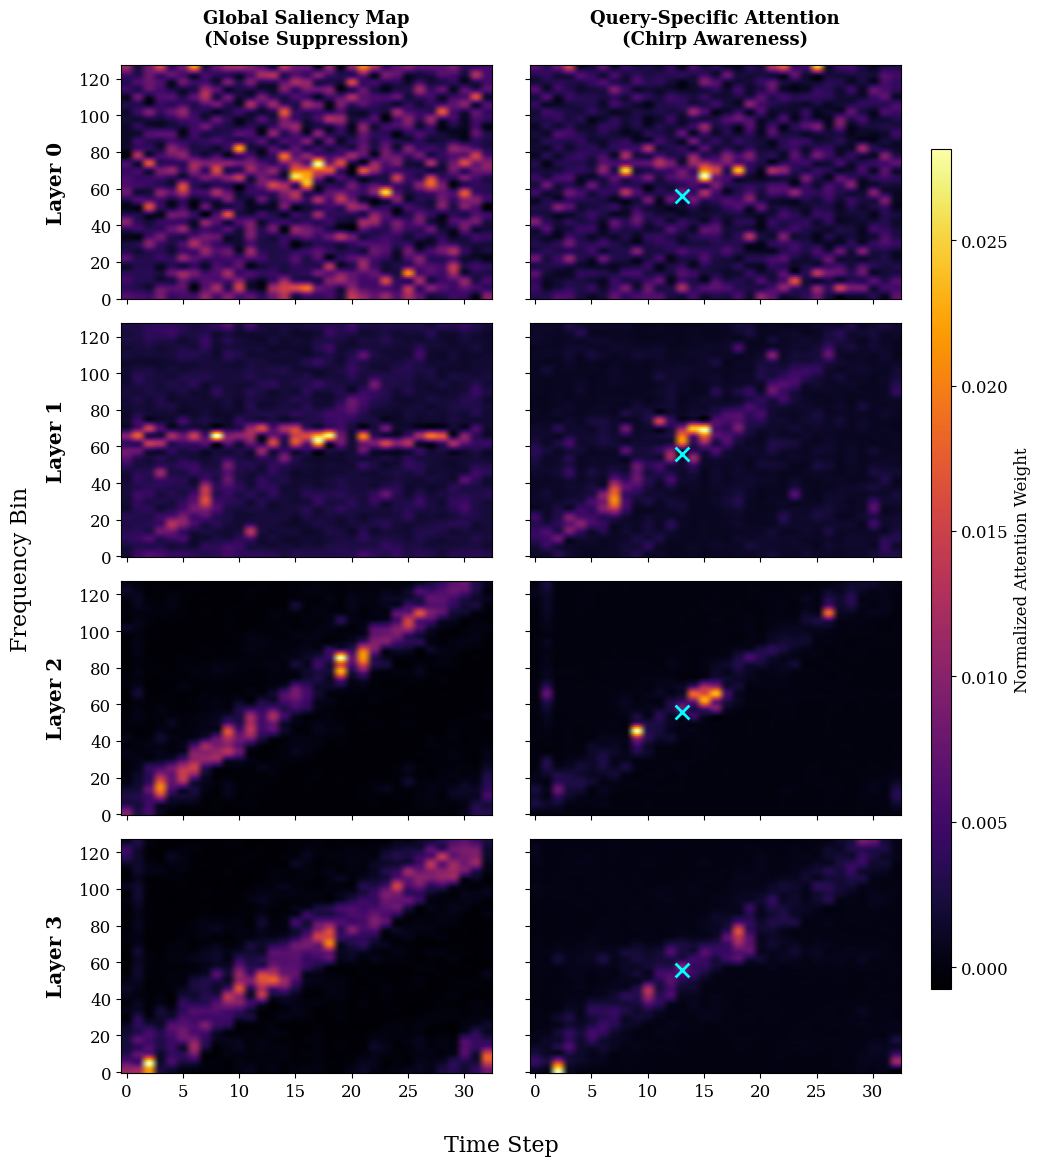

In [43]:
import torch.nn.functional as F

# ==========================================
# 1. Visualization Processing Function
# ==========================================
def process_attention_map(attn_maps, layer_idx, img_h=int(opts.n_classes/4), img_w=33, origin_h=int(opts.n_classes), query_point=None):
    """
    Attention Map을 가공하여 시각화할 이미지(Upsampled)로 변환하는 함수
    """
    # 1. 해당 레이어의 Attention Map 가져오기
    # attn_maps 구조가 [Layer1, Layer2, ...] 리스트라고 가정
    attn = attn_maps[layer_idx]
    
    # 배치 차원이 있다면 제거 (B, H, S, S) -> (H, S, S)
    if attn.dim() == 4: 
        attn = attn[0] 
        
    # 헤드 차원 평균 (Heads, Seq, Seq) -> (Seq, Seq)
    if attn.dim() == 3: 
        attn = attn.mean(dim=0) 
        
    # 2. Global vs Query-Specific 분기 처리
    if query_point is None:
        # [Mode A] Global Saliency (전체 평균)
        target_attn = attn.mean(dim=0) # (1056,)
    else:
        # [Mode B] Query-Specific (특정 픽셀 시점)
        qy, qx = query_point
        # Feature Map (32, 33) 기준 좌표를 Flatten Index로 변환
        q_idx = qy * img_w + qx 
        target_attn = attn[q_idx, :] # (1056,)

    # 3. 1D -> 2D Reshape (32 x 33)
    spatial_attn = target_attn.view(img_h, img_w)
    
    # 4. Upsampling to Original Size (128 x 33)
    # Bicubic Interpolation으로 부드럽게 확장
    spatial_attn_resized = F.interpolate(
        spatial_attn.unsqueeze(0).unsqueeze(0), 
        size=(origin_h, img_w), 
        mode='bicubic', 
        align_corners=False
    ).squeeze()
    
    return spatial_attn_resized.detach().cpu().numpy()


# ==========================================
# 2. Main Plotting Logic (Grid Layout)
# ==========================================

# --- [USER SETTINGS] ---
# 실제 데이터가 있다면 여기에 연결하세요.
attn_maps = viz_model.get_attention_maps()
# attn_maps = generate_mock_attn_maps() # 지금은 가짜 데이터 사용

# Chirp 위에 있는 좌표 (Feature Map 32x33 기준)
# 예: Time=15, Freq=15 (중간쯤)
query_point_chirp = (14, 13) 

# -----------------------

# 폰트 및 스타일 설정
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

# 4행 2열 그리드 생성
fig, axes = plt.subplots(4, 2, figsize=(10, 12), sharex=True, sharey=True)

# 행/열 제목 정의
col_titles = ["Global Saliency Map\n(Noise Suppression)", "Query-Specific Attention\n(Chirp Awareness)"]
row_titles = ["Layer 0", "Layer 1", "Layer 2", "Layer 3"]

# 전체 반복문
for i in range(4):
    # --- Data Preparation ---
    # 왼쪽: Global
    img_global = process_attention_map(attn_maps, layer_idx=i, query_point=None)
    # 오른쪽: Query-Specific
    img_specific = process_attention_map(attn_maps, layer_idx=i, query_point=query_point_chirp)
    
    # --- Plotting Left (Global) ---
    im1 = axes[i, 0].imshow(img_global, aspect='auto', origin='lower', cmap='inferno')
    
    # --- Plotting Right (Specific) ---
    im2 = axes[i, 1].imshow(img_specific, aspect='auto', origin='lower', cmap='inferno')
    
    # --- Marker (Right Only) ---
    # Feature Map 좌표를 원본(128x33) 좌표로 변환하여 찍기
    scale_y = 128 / 32
    real_qy = query_point_chirp[0] * scale_y
    real_qx = query_point_chirp[1] # 가로는 33으로 동일하므로 그대로
    
    # Cyan 색상으로 X 마커 표시 (검/붉은 배경에서 가장 잘 보임)
    axes[i, 1].scatter(real_qx, real_qy, c='cyan', marker='x', s=100, linewidth=2, label='Query' if i==0 else "")

    # --- Headers & Labels ---
    # 왼쪽 행 제목 (Layer N)
    axes[i, 0].set_ylabel(row_titles[i], rotation=90, size='large', weight='bold', labelpad=10)
    
    # 위쪽 열 제목 (맨 윗줄만)
    if i == 0:
        axes[i, 0].set_title(col_titles[0], pad=15, weight='bold', size=13)
        axes[i, 1].set_title(col_titles[1], pad=15, weight='bold', size=13)

# 공통 축 이름 설정 (보이지 않는 큰 프레임 사용)
fig.text(0.5, 0.02, 'Time Step', ha='center', va='center', size=16)
fig.text(0.02, 0.5, 'Frequency Bin', ha='center', va='center', rotation='vertical', size=16)

# 컬러바 (오른쪽에 하나만 깔끔하게 배치)
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
fig.colorbar(im2, cax=cbar_ax, label='Normalized Attention Weight')

# 레이아웃 조정
plt.subplots_adjust(left=0.12, right=0.9, top=0.92, bottom=0.08, wspace=0.1, hspace=0.1)

plt.show()

In [30]:
from scipy.stats import pearsonr, ttest_ind
import matplotlib.gridspec as gridspec

def compute_slope_selectivity_pixel_space(attention_map, sf):
    """
    Pixel space에서의 Slope Selectivity 분석
    
    Args:
        attention_map: [H, W] numpy array
                       SF7: [128, 33]
                       SF8: [256, 33]
                       SF9: [512, 33]
        sf: Spreading Factor (7, 8, 9)
    
    Returns:
        dict: 분석 결과
    """
    H, W = attention_map.shape
    
    # Pixel space에서의 이론적 chirp slope
    # Full chirp: (0,0) -> (H, W)
    mu_pixel = H / W
    
    print(f"\n{'='*60}")
    print(f"SF{sf} Analysis - Spectrogram shape: [{H}, {W}]")
    print(f"Expected pixel slope (μ): {mu_pixel:.3f} freq_bins/time_frame")
    print(f"{'='*60}\n")
    
    all_slopes = []
    all_attentions = []
    distances = []
    attentions = []
    attentions2 = []
    
    # 모든 (i, j) pair에 대해 pixel slope 계산
    for i in range(H):
        for j in range(W):
            # i: frequency bin index (0 to H-1)
            # j: time frame index (0 to W-1)
            
            # Reference point를 (0, 0)으로 설정
            # 각 point (i, j)의 slope = i / (j + epsilon)
            expected_freq = mu_pixel * j
            distance = abs(i-expected_freq)
            distances.append(distance)
            attentions2.append(attention_map[i,j])
            
            if j > 0:  # Avoid division by zero
                slope_ij = i / j  # pixels per frame
                slope_deviation = abs(slope_ij - mu_pixel)
                
                all_slopes.append(slope_deviation)
                all_attentions.append(attention_map[i, j])
    
    # Numpy 배열로 변환
    all_slopes = np.array(all_slopes)
    all_attentions = np.array(all_attentions)
    distances = np.array(distances)
    attentions = np.array(attentions)
    attentions2 = np.array(attentions2)
    # Pearson correlation
    correlation, p_value = pearsonr(all_slopes, all_attentions)
    correlation2, p_value2 = pearsonr(distances, attentions2)
    
    print(f"Number of (i,j) pairs analyzed: {len(all_slopes):,}")
    print(f"Slope deviation range: [{all_slopes.min():.2f}, {all_slopes.max():.2f}]")
    print(f"Attention range: [{all_attentions.min():.6f}, {all_attentions.max():.6f}]")
    
    return {
        'correlation': correlation,
        'p_value': p_value,
        'slopes': all_slopes,
        'attentions': all_attentions,
        'mu_pixel': mu_pixel,
        'H': H,
        'W': W,
        'sf': sf,
        'correlation2': correlation2,
        'p_value2': p_value2,
        'distances': distances,
        'attentions2': attentions2
    }


def compute_on_off_chirp_ratio_pixel(result, epsilon=0.3):
    """
    Pixel space 기준 On-chirp vs Off-chirp
    
    Args:
        epsilon: On-chirp threshold (|slope - μ| < epsilon * μ)
    """
    mu = result['mu_pixel']
    slopes = result['slopes']
    attentions = result['attentions']
    
    # Threshold (pixel space)
    threshold = epsilon * mu
    
    # On-chirp: slope deviation < threshold
    on_chirp_mask = slopes < threshold
    on_chirp_attn = attentions[on_chirp_mask]
    
    # Off-chirp: slope deviation > mu (large deviation)
    off_chirp_mask = slopes > mu
    off_chirp_attn = attentions[off_chirp_mask]
    
    if len(on_chirp_attn) == 0 or len(off_chirp_attn) == 0:
        print("Warning: Empty on-chirp or off-chirp set!")
        print(f"  On-chirp count: {len(on_chirp_attn)}")
        print(f"  Off-chirp count: {len(off_chirp_attn)}")
        
        # Adjust threshold
        threshold = np.percentile(slopes, 25)  # Lower 25%
        off_threshold = np.percentile(slopes, 75)  # Upper 25%
        
        on_chirp_mask = slopes < threshold
        off_chirp_mask = slopes > off_threshold
        
        on_chirp_attn = attentions[on_chirp_mask]
        off_chirp_attn = attentions[off_chirp_mask]
        
        print(f"Adjusted thresholds:")
        print(f"  On-chirp: slope < {threshold:.2f}")
        print(f"  Off-chirp: slope > {off_threshold:.2f}")
    
    # Statistics
    on_mean = on_chirp_attn.mean() if len(on_chirp_attn) > 0 else 0
    on_std = on_chirp_attn.std() if len(on_chirp_attn) > 0 else 0
    off_mean = off_chirp_attn.mean() if len(off_chirp_attn) > 0 else 0
    off_std = off_chirp_attn.std() if len(off_chirp_attn) > 0 else 0
    
    ratio = on_mean / off_mean if off_mean > 0 else float('inf')
    
    # T-test
    if len(on_chirp_attn) > 1 and len(off_chirp_attn) > 1:
        t_stat, t_pval = ttest_ind(on_chirp_attn, off_chirp_attn)
    else:
        t_stat, t_pval = 0, 1.0
    
    print(f"\n{'='*60}")
    print(f"On-chirp vs Off-chirp Analysis (SF{result['sf']})")
    print(f"{'='*60}")
    print(f"On-chirp  (slope deviation < {threshold:.2f}):")
    print(f"  Mean: {on_mean:.6f} ± {on_std:.6f}")
    print(f"  Count: {len(on_chirp_attn):,}")
    print(f"\nOff-chirp (slope deviation > {mu:.2f}):")
    print(f"  Mean: {off_mean:.6f} ± {off_std:.6f}")
    print(f"  Count: {len(off_chirp_attn):,}")
    print(f"\nRatio: {ratio:.2f}x")
    print(f"T-test: t={t_stat:.3f}, p={t_pval:.2e}")
    print(f"{'='*60}\n")
    
    return {
        'on_chirp_mean': on_mean,
        'on_chirp_std': on_std,
        'off_chirp_mean': off_mean,
        'off_chirp_std': off_std,
        'ratio': ratio,
        'on_chirp_count': len(on_chirp_attn),
        'off_chirp_count': len(off_chirp_attn),
        't_statistic': t_stat,
        't_pvalue': t_pval,
        'on_chirp_attn': on_chirp_attn,
        'off_chirp_attn': off_chirp_attn,
        'threshold': threshold
    }


def plot_slope_analysis_pixel(result, ratio_result, save_path=None):
    """
    시각화 (pixel space 기준)
    """
    sf = result['sf']
    if save_path is None:
        save_path = f'slope_analysis_SF{sf}_pixel.png'
    
    fig = plt.figure(figsize=(30,5))
    gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)
    
    slopes = result['slopes']
    attentions = result['attentions']
    mu = result['mu_pixel']
    
    # (a) Scatter plot
    ax1 = fig.add_subplot(gs[0, 0])
    
    if len(slopes) > 5000:
        idx = np.random.choice(len(slopes), 4000, replace=False)
        slopes_plot = slopes[idx]
        attns_plot = attentions[idx]
    else:
        slopes_plot = slopes
        attns_plot = attentions
    
    ax1.scatter(slopes_plot, attns_plot, alpha=0.3, s=10, c='#222222')
    
    # Regression line
    z = np.polyfit(slopes, attentions, 1)
    p = np.poly1d(z)
    x_line = np.linspace(slopes.min(), slopes.max(), 100)
    ax1.plot(x_line, p(x_line), linestyle="--", color= '#D32F2F',linewidth=2.5, 
             label=f'r = {result["correlation2"]:.3f}')
    
    # ax1.axvline(mu, color='green', linestyle=':', linewidth=2, 
    #             label=f'μ = {mu:.2f} pixels/frame')
    
    ax1.set_xlabel('Absolute Slope Deviation', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Attention Weight', fontsize=18, fontweight='bold')
    ax1.tick_params(labelsize=15)
    # ax1.set_title(f'(a) Slope Selectivity SF{sf} (p = {result["p_value"]:.2e})', 
    #               fontsize=14, fontweight='bold')
    ax1.legend(fontsize=18)
    ax1.grid(True, alpha=0.3)
    
    # # (b) Attention map
    # ax2 = fig.add_subplot(gs[0, 1])
    # im = ax2.imshow(result['attention_map'] if 'attention_map' in result else np.zeros((result['H'], result['W'])), 
    #                 cmap='inferno', aspect='auto', interpolation='nearest', origin='lower')
    
    # # Overlay expected chirp line
    # time_frames = np.arange(result['W'])
    # freq_bins_expected = mu * time_frames
    # ax2.plot(time_frames, freq_bins_expected, 'cyan', linewidth=2, 
    #          linestyle='--', label=f'Expected chirp slope')
    
    # ax2.set_xlabel('Time Frame', fontsize=13, fontweight='bold')
    # ax2.set_ylabel('Frequency bin', fontsize=13, fontweight='bold')
    # ax2.set_title(f'(b) Attention Map', 
    #               fontsize=14, fontweight='bold')
    # ax2.legend(fontsize=10, loc='upper left')
    # cbar = plt.colorbar(im, ax=ax2)
    # cbar.set_label('Attention Weight', fontsize=11)
    
    # (c) Distribution
    ax3 = fig.add_subplot(gs[0, 1])
    
    on_chirp = ratio_result['on_chirp_attn']
    off_chirp = ratio_result['off_chirp_attn']
    
    if len(on_chirp) > 0 and len(off_chirp) > 0:
        ax3.hist(on_chirp, bins=30, alpha=0.6, label='On-chirp', 
                 color='green', density=True)
        ax3.hist(off_chirp, bins=30, alpha=0.6, label='Off-chirp', 
                 color='red', density=True)
        # ax3.axvline(on_chirp.mean(), color='darkgreen', linestyle='--', 
        #             linewidth=3, label=f'On-chirp: {on_chirp.mean():.4f}')
        # ax3.axvline(off_chirp.mean(), color='darkred', linestyle='--', 
        #             linewidth=3, label=f'Off-chirp: {off_chirp.mean():.4f}')
    
    ax3.set_xlabel('Attention Weight', fontsize=16, fontweight='bold')
    ax3.set_ylabel('Density', fontsize=18, fontweight='bold')
    ax3.tick_params(labelsize=15)
    # ax3.set_title(f'(c) On-chirp vs Off-chirp (Ratio: {ratio_result["ratio"]:.2f}x)', 
    #               fontsize=14, fontweight='bold')
    ax3.legend(fontsize=18)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # (d) Binned analysis
    # gs = gridspec.GridSpec(1, 1)
    ax4 = fig.add_subplot(gs[0,2])

    # Define bins and labels (LaTeX formatting applied for mu)
    bins = [0, 0.1*mu, 0.5*mu, mu, 2*mu, np.inf] # np.inf handles max safely
    bin_labels = [
        r'$< 0.1\mu$',             # 0.1μ 미만
        r'$0.1\text{--}0.5\mu$',   # 0.1 ~ 0.5μ (En-dash 사용으로 범위 표현 명확화)
        r'$0.5\text{--}1.0\mu$',   # 0.5 ~ 1.0μ
        r'$1.0\text{--}2.0\mu$',   # 1.0 ~ 2.0μ
        r'$> 2.0\mu$'              # 2.0μ 초과
    ]

    binned_attns = []
    binned_stds = []
    binned_counts = []

    # Binning Process
    for i in range(len(bins)-1):
        mask = (slopes >= bins[i]) & (slopes < bins[i+1])
        if mask.sum() > 0:
            binned_attns.append(attentions[mask].mean())
            binned_stds.append(attentions[mask].std())
            binned_counts.append(mask.sum())
        else:
            binned_attns.append(0)
            binned_stds.append(0)
            binned_counts.append(0)

    x_pos = np.arange(len(bin_labels))

    # [Visual Style Update]
    # IEEE Style Color: Dark Slate Blue or similar professional tone
    bar_color = '#4E79A7' 
    error_color = 'black'

    # Bar Plot with Z-order (Grid behind bars)
    bars = ax4.bar(x_pos, binned_attns, yerr=binned_stds, 
                color=bar_color, edgecolor='black', linewidth=1.0, 
                capsize=5, error_kw={'ecolor': error_color, 'elinewidth': 1.5},
                alpha=0.9, zorder=3)

    # Grid Settings
    ax4.grid(True, which='major', axis='y', linestyle='--', alpha=0.5, zorder=0)

    # Add count labels (Engineering Insight: Sample size validation)
    for i, (bar, count) in enumerate(zip(bars, binned_counts)):
        height = bar.get_height()
        yerr = binned_stds[i]
        # Place text explicitly above the error bar
        ax4.text(bar.get_x() + bar.get_width()/2., 0 - 0.0002,
                f'n={count}', ha='center', va='bottom', fontsize=10, 
                fontweight='bold', color='#333333')

    # Axis Styling
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(bin_labels, rotation=0, ha='center', fontsize=11)
    ax4.tick_params(axis='y', labelsize=15)
    ax4.set_ylim(-0.0003,0.0038)

    # Labeling with LaTeX
    ax4.set_xlabel(r'Slope Deviation Range', fontsize=16, fontweight='bold')
    ax4.set_ylabel('Mean Attention Score', fontsize=18, fontweight='bold')

    # Title (Optional regarding paper format, but good for self-check)
    # ax4.set_title(r'(d) Attention Distribution vs. Slope Deviation', fontsize=14, pad=15)
    # ax4.set_title(f'(d) Attention Distribution vs. Slope Deviation', 
    #               fontsize=14, fontweight='bold')

    # Spines (Clean look)
    # ax4.spines['top'].set_visible(False)
    # ax4.spines['right'].set_visible(False)

    # plt.tight_layout()
    
    return fig


SF7 Analysis - Spectrogram shape: [128, 33]
Expected pixel slope (μ): 3.879 freq_bins/time_frame

Number of (i,j) pairs analyzed: 4,096
Slope deviation range: [0.00, 123.12]
Attention range: [0.000130, 0.016513]

Correlation: -0.0793

Correlation2: -0.4000
P-value: 3.69e-07
Pixel slope (μ): 3.879 freq_bins/time_frame

On-chirp vs Off-chirp Analysis (SF7)
On-chirp  (slope deviation < 1.16):
  Mean: 0.001842 ± 0.001718
  Count: 1,097

Off-chirp (slope deviation > 3.88):
  Mean: 0.000545 ± 0.000447
  Count: 984

Ratio: 3.38x
T-test: t=22.989, p=2.17e-104



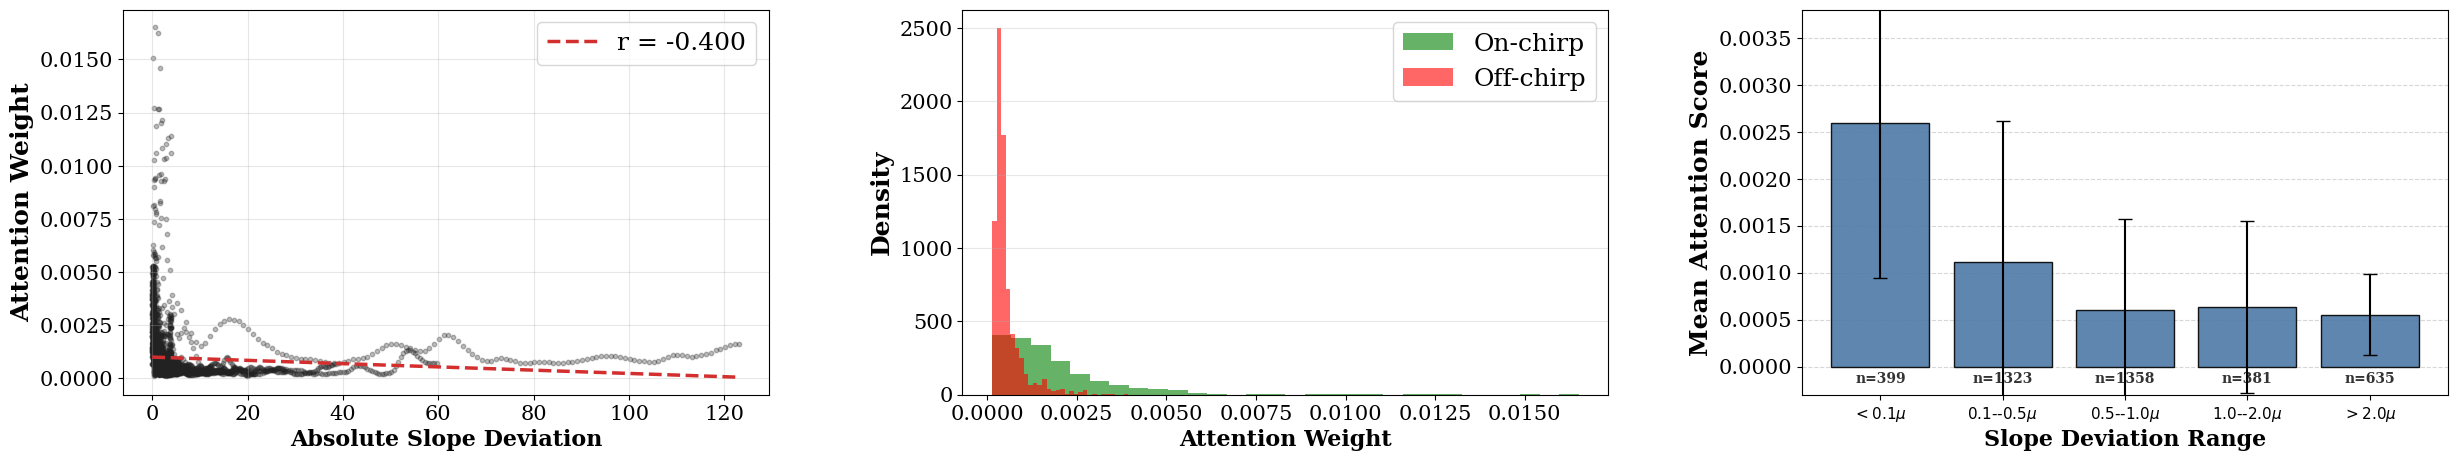

In [31]:
# Attention map 로드 (예시)
# attention_map = np.load('attention_SF7.npy')  # [128, 33]
attention_map = img_global

sf = opts.sf

# 분석
result = compute_slope_selectivity_pixel_space(attention_map, sf)
# result = compute_final_diagonal_analysis(attention_map, sf=opts.sf)

print(f"\nCorrelation: {result['correlation']:.4f}")
print(f"\nCorrelation2: {result['correlation2']:.4f}")
print(f"P-value: {result['p_value']:.2e}")
print(f"Pixel slope (μ): {result['mu_pixel']:.3f} freq_bins/time_frame")

# On/off-chirp 비교
ratio_result = compute_on_off_chirp_ratio_pixel(result, epsilon=0.3)
# comparison = compute_on_off_diagonal_comparison(result, threshold_pixels=int(5*(opts.sf-6)))

# 시각화
result['attention_map'] = attention_map  # Add for plotting
fig = plot_slope_analysis_pixel(result, ratio_result)